Original Data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

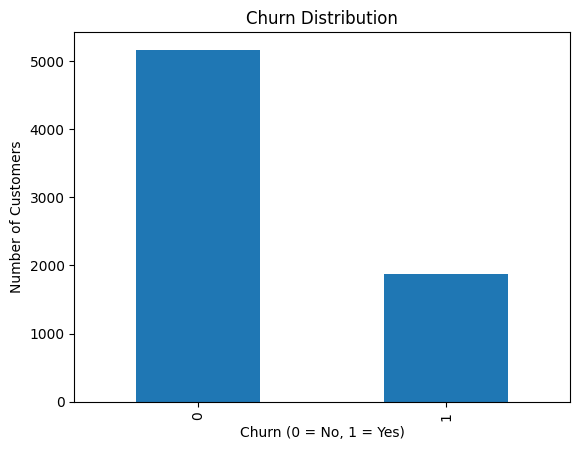

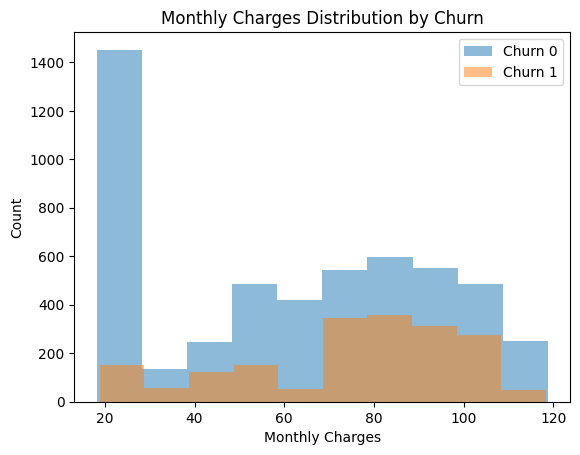

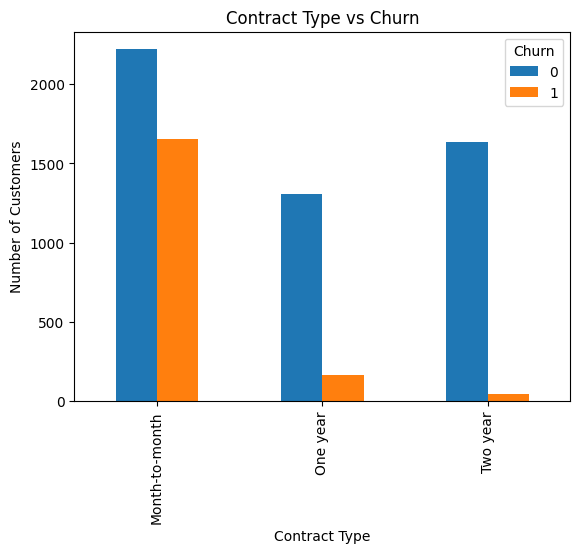

In [1]:
#Data Visualization from Extraction Transformation and Loading (ETL) Process.


# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. EXTRACT
# -------------------------
# Load dataset
data = pd.read_csv('Telco-Customer-Churn3.csv')

print("Original Data:")
print(data.head())

# -------------------------
# 2. TRANSFORM
# -------------------------

# Remove customerID (not useful for analysis)
data = data.drop(columns=['customerID'])

# Convert TotalCharges to numeric (it may contain spaces)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Remove missing values
data = data.dropna()

# Convert Churn to numeric (Yes=1, No=0)
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print("\nCleaned Data:")
print(data.head())

# -------------------------
# 3. LOAD
# -------------------------
# Save cleaned data
data.to_csv('cleaned_telco_data.csv', index=False)

# -------------------------
# 4. VISUALIZATION
# -------------------------

# --- 1. Churn Count ---
churn_count = data['Churn'].value_counts()

plt.figure()
churn_count.plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

# --- 2. Monthly Charges vs Churn ---
plt.figure()

for churn_value in data['Churn'].unique():
    subset = data[data['Churn'] == churn_value]
    plt.hist(subset['MonthlyCharges'], alpha=0.5, label=f'Churn {churn_value}')

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend()

plt.show()

# --- 3. Contract Type vs Churn ---
contract_churn = pd.crosstab(data['Contract'], data['Churn'])

contract_churn.plot(kind='bar')

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Data Visualization from ETL Process

# This program demonstrates the ETL process, which stands for Extract, Transform, and Load. In this program, customer churn data is first extracted from a CSV file, then transformed by cleaning the dataset, and finally loaded into a new cleaned CSV file. After that, the cleaned data is visualized using graphs to understand customer churn patterns.

# Theory

# ETL is a data processing method used to collect data from a source, clean and modify it, and store it in a final usable form. It is widely used in data analysis, business intelligence, and data warehousing. In this program, ETL helps convert raw customer data into meaningful information for analysis. The visualization part helps us identify which customers are more likely to churn and what factors may affect churn.

# What the Program Did

# The program loaded the Telco customer churn dataset from a CSV file. Then it removed the customerID column because it is not useful for analysis. It converted the TotalCharges column into numeric form because some values may contain spaces or invalid text. It removed missing values using dropna(). It also changed the Churn column from text values Yes/No to numeric values 1/0. After cleaning the data, it saved the cleaned dataset into a new CSV file. Finally, it created three graphs to analyze churn behavior.

# Benefits

# This process is useful because it cleans raw data before analysis, removes unnecessary columns, handles missing values, and makes the dataset ready for machine learning or reporting. The graphs help in quickly understanding patterns such as churn distribution, monthly charge behavior, and contract type influence on churn. This makes decision-making easier for businesses.

# Code Explanation: Major Important Parts

# The import statements load pandas for data handling and matplotlib.pyplot for plotting graphs.

# The line data = pd.read_csv('Telco-Customer-Churn3.csv') reads the dataset from the CSV file.

# The line data = data.drop(columns=['customerID']) removes the customerID column because it does not help in predicting churn.

# The line data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce') converts TotalCharges into numeric form. If any invalid value is found, it becomes missing.

# The line data = data.dropna() removes rows with missing values, so the dataset becomes clean.

# The line data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0}) converts churn labels into numeric form. This is important because machine learning and analysis often work better with numbers.

# The line data.to_csv('cleaned_telco_data.csv', index=False) saves the cleaned dataset for future use.

# The three graph sections are used for data visualization and insight generation.

# Explanation of Output

# Original Data:
# This output shows the raw dataset exactly as it was loaded from the CSV file. It contains columns like customerID, gender, tenure, MonthlyCharges, TotalCharges, Contract, and Churn.

# Cleaned Data:
# This output shows the dataset after preprocessing. The customerID column is removed, TotalCharges is converted into numeric values, missing values are removed, and Churn is changed from Yes/No to 1/0. This cleaned data is more suitable for analysis.

# Graph 1: Churn Distribution
# This bar chart shows how many customers churned and how many stayed.

# How to read it:

# * X-axis shows churn class:

#   * 0 = No churn
#   * 1 = Yes churn
# * Y-axis shows number of customers

# What it says:
# The graph shows that non-churn customers are much more than churn customers. This means most customers stayed, while a smaller number left the service. This also shows class imbalance in the dataset.

# Graph 2: Monthly Charges Distribution by Churn
# This histogram compares monthly charges for churned and non-churned customers.

# How to read it:

# * X-axis shows MonthlyCharges
# * Y-axis shows count of customers
# * Blue bars represent churn = 0
# * Orange bars represent churn = 1

# What it says:
# This graph helps compare whether customers with higher monthly charges are more likely to churn. If the orange bars are more visible in higher charge ranges, it suggests that customers paying more may be leaving more often. This is useful for understanding the relation between price and churn.

# Graph 3: Contract Type vs Churn
# This bar chart shows churn behavior based on contract type.

# How to read it:

# * X-axis shows contract type:

#   * Month-to-month
#   * One year
#   * Two year
# * Y-axis shows number of customers
# * Different colors show churn and non-churn customers

# What it says:
# This graph shows that month-to-month customers churn more compared to one-year and two-year customers. Long-term contracts usually reduce churn because customers stay connected for a longer time. This is one of the most important business insights from the dataset.

# Conclusion

# This program successfully demonstrates ETL and data visualization. It extracts raw churn data, transforms it into a clean format, saves the cleaned data, and then visualizes the results. The graphs provide useful insights into churn behavior, monthly charges, and contract types. This helps businesses understand customer behavior and take actions to reduce churn.
